In [1]:
# pip install "numpy<2.0" 

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
pd.set_option('display.max_columns',None)

In [79]:
df = pd.read_csv('gurgaon_properties_missing_value_imputation.csv')

In [80]:
df.shape

(3559, 18)

In [81]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,bptp terra,sector 37d,1.60,7303.0,4,3,3+,7.0,Relatively New,2000.0,0,0,0,0,1,1,139
1,flat,dlf express greens,manesar,1.60,6809.0,4,6,3+,4.0,Relatively New,2611.0,1,1,0,1,0,0,49
2,flat,mapsko royale ville,sector 82,1.12,8000.0,3,4,2,6.0,Relatively New,1500.0,0,1,0,1,0,1,174
3,flat,dlf regal gardens,sector 90,1.25,7340.0,3,3,3,28.0,Moderately Old,1540.0,0,1,0,0,0,0,38
4,flat,sare green parc,sector 92,0.85,6741.0,3,2,2,14.0,Relatively New,1261.0,0,0,0,0,0,0,0


In [82]:
train_df = df.drop(columns=['society','price_per_sqft'])

In [83]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,sector 37d,1.60,4,3,3+,7.0,Relatively New,2000.0,0,0,0,0,1,1,139
1,flat,manesar,1.60,4,6,3+,4.0,Relatively New,2611.0,1,1,0,1,0,0,49
2,flat,sector 82,1.12,3,4,2,6.0,Relatively New,1500.0,0,1,0,1,0,1,174
3,flat,sector 90,1.25,3,3,3,28.0,Moderately Old,1540.0,0,1,0,0,0,0,38
4,flat,sector 92,0.85,3,2,2,14.0,Relatively New,1261.0,0,0,0,0,0,0,0


## luxury score

<Axes: xlabel='luxury_score'>

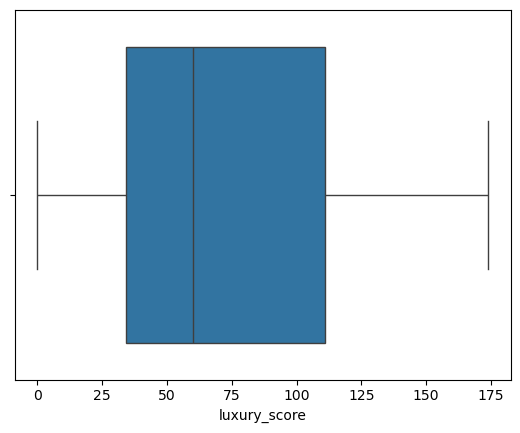

In [84]:
sns.boxplot(x=df['luxury_score'])

In [85]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return 'Low'
    elif 50 <= score < 150:
        return 'Medium'
    elif 150 <= score <=175:
        return 'High'
    else:
        return None # or "Undefined" or any other label for scores outside the defined bins

In [86]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

In [87]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
0,flat,sector 37d,1.60,4,3,3+,7.0,Relatively New,2000.0,0,0,0,0,1,1,139,Medium
1,flat,manesar,1.60,4,6,3+,4.0,Relatively New,2611.0,1,1,0,1,0,0,49,Low
2,flat,sector 82,1.12,3,4,2,6.0,Relatively New,1500.0,0,1,0,1,0,1,174,High
3,flat,sector 90,1.25,3,3,3,28.0,Moderately Old,1540.0,0,1,0,0,0,0,38,Low
4,flat,sector 92,0.85,3,2,2,14.0,Relatively New,1261.0,0,0,0,0,0,0,0,Low


## floorNum

<Axes: xlabel='floorNum'>

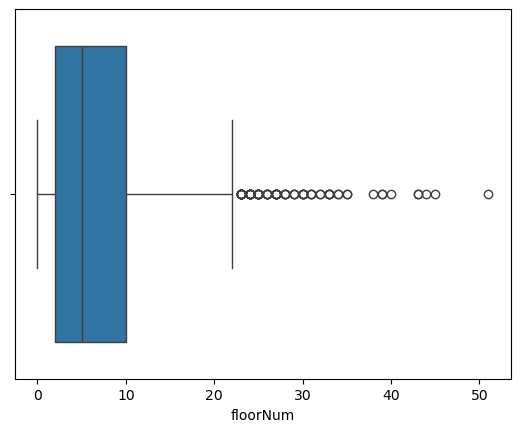

In [88]:
sns.boxplot(x=df['floorNum'])

In [89]:
def categorize_floor(floor):
    if 0 <= floor <=2:
        return "Low Floor"
    elif 3 <= floor <=10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None # or "Undefined" or any other label for floors outside the defined bins

In [90]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [91]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,flat,sector 37d,1.60,4,3,3+,7.0,Relatively New,2000.0,0,0,0,0,1,1,139,Medium,Mid Floor
1,flat,manesar,1.60,4,6,3+,4.0,Relatively New,2611.0,1,1,0,1,0,0,49,Low,Mid Floor
2,flat,sector 82,1.12,3,4,2,6.0,Relatively New,1500.0,0,1,0,1,0,1,174,High,Mid Floor
3,flat,sector 90,1.25,3,3,3,28.0,Moderately Old,1540.0,0,1,0,0,0,0,38,Low,High Floor
4,flat,sector 92,0.85,3,2,2,14.0,Relatively New,1261.0,0,0,0,0,0,0,0,Low,High Floor


In [92]:
train_df.drop(columns=['floorNum','luxury_score'], inplace=True)

In [93]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,flat,sector 37d,1.60,4,3,3+,Relatively New,2000.0,0,0,0,0,1,1,Medium,Mid Floor
1,flat,manesar,1.60,4,6,3+,Relatively New,2611.0,1,1,0,1,0,0,Low,Mid Floor
2,flat,sector 82,1.12,3,4,2,Relatively New,1500.0,0,1,0,1,0,1,High,Mid Floor
3,flat,sector 90,1.25,3,3,3,Moderately Old,1540.0,0,1,0,0,0,0,Low,High Floor
4,flat,sector 92,0.85,3,2,2,Relatively New,1261.0,0,0,0,0,0,0,Low,High Floor


In [94]:
from sklearn.preprocessing import OrdinalEncoder

# Create a copy of the original data for label encoding
data_label_encoded = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns

# Apply label encoding to categorical columns
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

# Splitting the dataset into training and testing sets
X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']
    

[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'new',
       'new sector 2', 'sector 1', 'sector 102', 'sector 103',
       'sector 104', 'sector 105', 'sector 106', 'sector 107',
       'sector 108', 'sector 109', 'sector 10a', 'sector 11',
       'sector 110', 'sector 111', 'sector 112', 'sector 113',
       'sector 12', 'sector 13', 'sector 14', 'sector 15', 'sector 17',
       'sector 17a', 'sector 17b', 'sector 2', 'sector 21', 'sector 22',
       'sector 23', 'sector 24', 'sector 25', 'sector 26', 'sector 27',
       'sector 28', 'sector 3', 'sector 3 phase 2',
       'sector 3 phase 3 extension', 'sector 30', 'sector 31',
       'sector 33', 'sector 36', 'sector 36a', 'sector 37c', 'sector 37d',
       'sector 38', 'sector 39', 'sector 4', 'sector 40', 'sector 41',
       'sector 43', 'sector 45', 'sector 46', 'sector 47', 'sector 48',
       'sector 49', 'sector 5', 'sector 50', 'sector 51', 'sector 52',
       'sector 53', 'sect

In [95]:
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,45.0,4,3,4.0,3.0,2000.0,0,0,0,0,1,1,2.0,2.0
1,0.0,2.0,4,6,4.0,3.0,2611.0,1,1,0,1,0,0,1.0,2.0
2,0.0,94.0,3,4,2.0,3.0,1500.0,0,1,0,1,0,1,0.0,2.0
3,0.0,104.0,3,3,3.0,0.0,1540.0,0,1,0,0,0,0,1.0,0.0
4,0.0,106.0,3,2,2.0,3.0,1261.0,0,0,0,0,0,0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3554,0.0,13.0,3,4,3.0,3.0,2337.0,0,1,0,0,0,0,2.0,0.0
3555,0.0,12.0,2,3,3.0,3.0,1160.0,0,0,0,0,0,0,2.0,2.0
3556,0.0,98.0,3,4,2.0,1.0,1616.0,0,1,0,0,0,0,1.0,2.0
3557,0.0,87.0,2,2,3.0,3.0,1198.0,0,0,0,0,0,1,1.0,0.0


In [96]:
y_label

0       1.60
1       1.60
2       1.12
3       1.25
4       0.85
        ... 
3554    2.25
3555    0.93
3556    1.45
3557    0.75
3558    2.40
Name: price, Length: 3559, dtype: float64

## Technique 1 - Correlation Analysis

<Axes: >

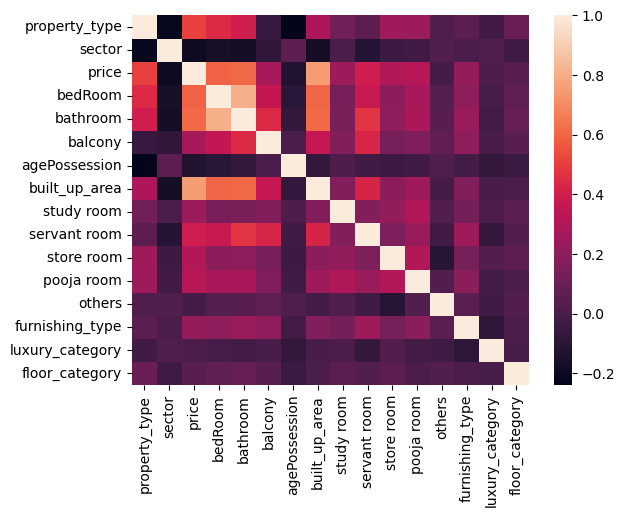

In [97]:
sns.heatmap(data_label_encoded.corr())

In [99]:
fi_df1 = data_label_encoded.corr()['price'].iloc[0:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1 = fi_df1[fi_df1['feature'] != 'price']
fi_df1

,feature,corr_coeff
0,property_type,0.502510
1,sector,-0.196123
3,bedRoom,0.590692
4,bathroom,0.609156
5,balcony,0.269938
6,agePossession,-0.132040
7,built_up_area,0.748454
8,study room,0.242618
9,servant room,0.391658
10,store room,0.305796


## Technique 2 - Random Forest Feature Importance

In [100]:
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df2

,feature,rf_importance
6,built_up_area,0.648506
0,property_type,0.103975
1,sector,0.101621
3,bathroom,0.024672
2,bedRoom,0.023342
8,servant room,0.020192
5,agePossession,0.015182
4,balcony,0.012099
12,furnishing_type,0.010828
9,store room,0.008737


## Technique 3 - Gradient Boosting Feature importance

In [101]:
from sklearn.ensemble import GradientBoostingRegressor

# Train a Random Forest regressor on Label encoded data
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
6,built_up_area,0.680173
1,sector,0.099092
0,property_type,0.097630
2,bedRoom,0.039332
3,bathroom,0.036410
8,servant room,0.024343
9,store room,0.009031
5,agePossession,0.004276
7,study room,0.003653
12,furnishing_type,0.002995


In [102]:
fi_df3

,feature,gb_importance
6,built_up_area,0.680173
1,sector,0.099092
0,property_type,0.097630
2,bedRoom,0.039332
3,bathroom,0.036410
8,servant room,0.024343
9,store room,0.009031
5,agePossession,0.004276
7,study room,0.003653
12,furnishing_type,0.002995


## Technique 4 - Permutation Importance

In [103]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 =  pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
6,built_up_area,0.773376
0,property_type,0.219878
1,sector,0.153031
2,bedRoom,0.039818
3,bathroom,0.020974
8,servant room,0.008597
5,agePossession,0.005428
4,balcony,0.004525
12,furnishing_type,0.001128
14,floor_category,0.000901


## Technique 5 - LASSO

In [104]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train a LASSO regression model 
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
6,built_up_area,1.512400
0,property_type,0.710454
3,bathroom,0.273136
9,store room,0.200569
7,study room,0.170952
12,furnishing_type,0.160881
8,servant room,0.160540
10,pooja room,0.072886
13,luxury_category,0.052332
2,bedRoom,0.017259


## Technique 6 - RFE (Recursive feature elimination)

In [105]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data 
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame 
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6

,feature,rfe_score
6,built_up_area,0.644988
0,property_type,0.102619
1,sector,0.102203
2,bedRoom,0.028173
3,bathroom,0.025545
8,servant room,0.017754
5,agePossession,0.015148
4,balcony,0.012579
12,furnishing_type,0.010756
9,store room,0.009494


## Technique 7 - Linear Regression Weights

In [106]:
# Train a Linear regression model on the label-encoded and standardized training data
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7

,feature,reg_coeffs
6,built_up_area,1.514782
0,property_type,0.708095
3,bathroom,0.280592
9,store room,0.205193
7,study room,0.179417
12,furnishing_type,0.169968
8,servant room,0.169311
10,pooja room,0.076063
13,luxury_category,0.063048
2,bedRoom,0.019652


## Technique 8 - SHAP

In [30]:
import shap

# Compute SHAP values using the trained Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label, y_label)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_label)


# Summing the absolute SHAP values across all samples to get an overall measure of feature importance
shap_sum = np.abs(shap_values).mean(axis=0)

shap_values

array([[-0.39345521, -0.02980102,  0.04782278, ...,  0.01288158,
        -0.05047922, -0.04405352],
       [-0.58917041, -1.16607524,  0.05050329, ..., -0.03167983,
        -0.00214512, -0.0484757 ],
       [-0.2552178 , -0.3291898 , -0.00918665, ...,  0.00387758,
         0.02076261, -0.00255225],
       ...,
       [-0.2419627 , -0.4461951 , -0.01180416, ..., -0.01363611,
        -0.00246497, -0.00308674],
       [-0.157418  , -0.06666893, -0.04256178, ..., -0.00153715,
        -0.00415831,  0.02869641],
       [-0.39230597, -0.24342526, -0.04433219, ..., -0.00360912,
         0.04137697, -0.0198709 ]])

In [107]:
fi_df8 = pd.DataFrame({
    'feature': X_label.columns,
    'SHAP_score': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_score', ascending=False)

fi_df8

,feature,SHAP_score
6,built_up_area,1.245787
0,property_type,0.478055
1,sector,0.370462
3,bathroom,0.111237
8,servant room,0.094425
2,bedRoom,0.054864
4,balcony,0.039158
12,furnishing_type,0.027942
5,agePossession,0.026676
14,floor_category,0.025510


In [108]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').merge(fi_df8,on='feature').set_index('feature')

In [109]:
final_fi_df

,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs,SHAP_score
feature,,,,,,,,
property_type,0.502510,0.103975,0.097630,0.219878,0.710454,0.102619,0.708095,0.478055
sector,-0.196123,0.101621,0.099092,0.153031,-0.050415,0.102203,-0.059466,0.370462
bedRoom,0.590692,0.023342,0.039332,0.039818,0.017259,0.028173,0.019652,0.054864
bathroom,0.609156,0.024672,0.036410,0.020974,0.273136,0.025545,0.280592,0.111237
balcony,0.269938,0.012099,0.002000,0.004525,-0.041298,0.012579,-0.064186,0.039158
agePossession,-0.132040,0.015182,0.004276,0.005428,-0.029349,0.015148,-0.037279,0.026676
built_up_area,0.748454,0.648506,0.680173,0.773376,1.512400,0.644988,1.514782,1.245787
study room,0.242618,0.007937,0.003653,-0.002948,0.170952,0.008133,0.179417,0.019638
servant room,0.391658,0.020192,0.024343,0.008597,0.160540,0.017754,0.169311,0.094425


In [110]:
# normalize the score
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)
final_fi_df

,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs,SHAP_score
feature,,,,,,,,
property_type,0.128347,0.103975,0.097630,0.179682,0.222810,0.102619,0.222356,0.187691
sector,-0.050092,0.101621,0.099092,0.125055,-0.015811,0.102203,-0.018674,0.145449
bedRoom,0.150870,0.023342,0.039332,0.032539,0.005413,0.028173,0.006171,0.021540
bathroom,0.155586,0.024672,0.036410,0.017140,0.085660,0.025545,0.088111,0.043673
balcony,0.068946,0.012099,0.002000,0.003698,-0.012952,0.012579,-0.020156,0.015374
agePossession,-0.033725,0.015182,0.004276,0.004436,-0.009204,0.015148,-0.011706,0.010473
built_up_area,0.191165,0.648506,0.680173,0.631994,0.474312,0.644988,0.475671,0.489113
study room,0.061968,0.007937,0.003653,-0.002409,0.053613,0.008133,0.056340,0.007710
servant room,0.100034,0.020192,0.024343,0.007026,0.050348,0.017754,0.053167,0.037073


In [111]:
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score','SHAP_score']].mean(axis=1).sort_values(ascending=False)

feature
built_up_area      0.618955
property_type      0.134319
sector             0.114684
bathroom           0.029488
bedRoom            0.028985
servant room       0.021277
agePossession      0.009903
balcony            0.009150
furnishing_type    0.007294
store room         0.006633
study room         0.005005
floor_category     0.004751
luxury_category    0.004051
pooja room         0.003729
others             0.001775
dtype: float64

In [112]:
# to drop pooja room, study room, others
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,45.0,4,3,4.0,3.0,2000.0,0,0,0,0,1,1,2.0,2.0
1,0.0,2.0,4,6,4.0,3.0,2611.0,1,1,0,1,0,0,1.0,2.0
2,0.0,94.0,3,4,2.0,3.0,1500.0,0,1,0,1,0,1,0.0,2.0
3,0.0,104.0,3,3,3.0,0.0,1540.0,0,1,0,0,0,0,1.0,0.0
4,0.0,106.0,3,2,2.0,3.0,1261.0,0,0,0,0,0,0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3554,0.0,13.0,3,4,3.0,3.0,2337.0,0,1,0,0,0,0,2.0,0.0
3555,0.0,12.0,2,3,3.0,3.0,1160.0,0,0,0,0,0,0,2.0,2.0
3556,0.0,98.0,3,4,2.0,1.0,1616.0,0,1,0,0,0,0,1.0,2.0
3557,0.0,87.0,2,2,3.0,3.0,1198.0,0,0,0,0,0,1,1.0,0.0


In [113]:
 # with all the columns
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

In [114]:
scores.mean()

0.8183666898700013

In [115]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scroes = cross_val_score(rf, X_label.drop(columns=['pooja room','study room', 'others']), y_label, cv=5, scoring='r2')

In [116]:
scores.mean()

0.8183666898700013

In [117]:
export_df = X_label.drop(columns=['pooja room', 'study room', 'others'])
export_df['price'] = y_label

In [118]:
export_df.to_csv('gurgaon_properties_post_feature_selection.csv', index=False)

In [119]:
export_df

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category,price
0,0.0,45.0,4,3,4.0,3.0,2000.0,0,0,1,2.0,2.0,1.60
1,0.0,2.0,4,6,4.0,3.0,2611.0,1,0,0,1.0,2.0,1.60
2,0.0,94.0,3,4,2.0,3.0,1500.0,1,0,1,0.0,2.0,1.12
3,0.0,104.0,3,3,3.0,0.0,1540.0,1,0,0,1.0,0.0,1.25
4,0.0,106.0,3,2,2.0,3.0,1261.0,0,0,0,1.0,0.0,0.85
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3554,0.0,13.0,3,4,3.0,3.0,2337.0,1,0,0,2.0,0.0,2.25
3555,0.0,12.0,2,3,3.0,3.0,1160.0,0,0,0,2.0,2.0,0.93
3556,0.0,98.0,3,4,2.0,1.0,1616.0,1,0,0,1.0,2.0,1.45
3557,0.0,87.0,2,2,3.0,3.0,1198.0,0,0,1,1.0,0.0,0.75
